In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
import numpy as np
from PIL import Image
import os
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

In [ ]:
#load the all the images lcoated int eh folder dill and convert them to numpy arrays

all_images = []
for filename in os.listdir("/home/jouell/code/jouell3/plant_detect/data/raw/dill"):
    if filename.endswith(".jpg"):     
        image = Image.open("/home/jouell/code/jouell3/plant_detect/data/raw/dill/" + filename)
        # save the image with a new name
        #with Image.open("/home/jouell/code/jouell3/plant_detect/data/raw/dill/" + filename) as img:
        #    img.save("/home/jouell/code/jouell3/plant_detect/data/raw/dill/" + f"dill_{filename}")
        image_np = np.array(image)
        all_images.append(image_np)
all_images = np.array(all_images)
all_images.shape

In [ ]:
## this allow allow to rename all teh images located in a folder with the name of the folder as prefix, for example dill_0.jpg, dill_1.jpg, etc.



folder = Path("/home/jouell/code/jouell3/plant_detect/data/raw/lavender")
prefix = folder.name

for path in sorted(folder.glob("*.jpg")):
    if not path.stem.startswith(f"{prefix}_"):  # skip already-renamed files
        new_path = path.parent / f"{prefix}_{path.name}"
        path.rename(new_path)
        print(f"{path.name} → {new_path.name}")

print("Done.")


In [ ]:
labels = pd.read_csv("/home/jouell/code/jouell3/plant_detect/data/labels.csv")
labels.head()

In [ ]:
labels_3 = pd.read_csv("/home/jouell/code/jouell3/plant_detect/data/labels.csv")
labels_3.head()

In [ ]:
project_root = Path("/home/jouell/code/jouell3/plant_detect")
out_dir = project_root / "data/dataset_aromatic_plants/all_images"
out_dir.mkdir(parents=True, exist_ok=True)



for i, row in labels_3.iterrows():
    src = project_root / row.filename
    dst = out_dir / Path(row.filename).name
    with Image.open(src) as image:
        image.save(dst)

In [ ]:
labels.to_csv(project_root / "data/labels2.csv", index=False)

In [ ]:
labels_2 = pd.read_csv("/home/jouell/code/jouell3/plant_detect/data/labels2.csv")
labels_2.head()

In [ ]:
for i, row in enumerate(labels_2.itertuples()):
    name = row.filename.split("/")[-1]
    new_name = name.split("_")[0]
    labels_2.at[i, 'name'] = new_name
    print(labels_2.at[i, 'name'])

In [ ]:
labels_2.to_csv("/home/jouell/code/jouell3/plant_detect/data/labels2.csv", index=False)

In [ ]:
new_images = pd.read_csv("/home/jouell/code/jouell3/plant_detect/data/dataset_aromatic_plants/dataset_fennel.csv")
new_images.head()

In [ ]:
files_df = []
name = "fennel"
IMAGE_PATH = "/home/jouell/code/jouell3/plant_detect/data/dataset_aromatic_plants/fennel4/"
project_root = Path("/home/jouell/code/jouell3/plant_detect")
for i, row in new_images.iterrows():
    src = IMAGE_PATH + row.image_path.split("/")[-1]
    dst = project_root / "data/dataset_aromatic_plants/all_images2" / row.image_path.split("/")[-1]
    files_df.append({'filename': row.image_path.split("/")[-1], 'name': name})
    with Image.open(src) as image:
        image.save(dst)

In [ ]:
pd.DataFrame(files_df).to_csv("/home/jouell/code/jouell3/plant_detect/data/dataset_aromatic_plants/dataset_fennel2.csv", index=False)

In [10]:
#combining all the dataset with the name labels into one dataset
# files are either located in the folders data/dataset_flowers or data/dataset_fruits
# we first need to grab all teh csv files thata re located within these folder and contains the labels_*.csv in their name and then combine them into one dataset


for folder in ["../data/dataset_flowers", "../data/dataset_fruits"]:
    all_labels = []
    for filename in os.listdir(folder):
        if filename.startswith("labels_") and filename.endswith(".csv"):
            df = pd.read_csv(os.path.join(folder, filename))
            split_filename = filename.split("_")[1]
            plant_name = split_filename.split(".")[0]  # get the plant name from the filename
            df["filename"] = df["filename"].apply(lambda x: os.path.join(plant_name, x))
            all_labels.append(df)
    combined_labels = pd.concat(all_labels, ignore_index=True)
    combined_labels.to_csv(os.path.join(folder, "dataset_combined.csv"), index=False)

In [22]:
labels_3 = pd.read_csv("/home/jouell/code/jouell3/plant_detect2/data/dataset_flowers/dataset_combined.csv")
labels_3.head()

,filename,label,name
0,hellebore/hellebore_0003.jpg,good,hellebore
1,hellebore/hellebore_0004.jpg,good,hellebore
2,hellebore/hellebore_0006.jpg,good,hellebore
3,hellebore/hellebore_0010.jpg,good,hellebore
4,hellebore/hellebore_0011.jpg,good,hellebore


In [23]:
project_root = Path("/home/jouell/code/jouell3/plant_detect2/data/dataset_flowers")
out_dir = project_root / "all_images"
out_dir.mkdir(parents=True, exist_ok=True)



for i, row in labels_3.iterrows():
    src = project_root / row.filename
    dst = out_dir / Path(row.filename).name
    with Image.open(src) as image:
        image.save(dst)

In [26]:
labels_4 = pd.read_csv("/home/jouell/code/jouell3/plant_detect2/data/dataset_fruits/dataset_combined.csv")
labels_4.head()

,filename,label,name
0,blueberry/blueberry_0006.jpg,good,blueberry
1,blueberry/blueberry_0010.jpg,good,blueberry
2,blueberry/blueberry_0013.jpg,good,blueberry
3,blueberry/blueberry_0015.jpg,good,blueberry
4,blueberry/blueberry_0018.jpg,good,blueberry


In [18]:
project_root2 = Path("/home/jouell/code/jouell3/plant_detect2/data/dataset_enhanced")
out_dir = project_root2 / "all_images"
out_dir.mkdir(parents=True, exist_ok=True)



for i, row in new_labels2.iterrows():
    src = project_root2 / row.image_path
    dst = out_dir / Path(row.image_path).name
    with Image.open(src) as image:
        image.save(dst)

In [28]:
all_labels = pd.concat([labels_3, labels_4], ignore_index=True)
all_labels.to_csv("/home/jouell/code/jouell3/plant_detect2/data/all_labels.csv", index=False)

In [ ]:
new_labels = pd.read_csv("/home/jouell/code/jouell3/plant_detect2/data/all_labels.csv")
all_labels.head()

In [19]:
new_labels2 = pd.read_csv("/home/jouell/code/jouell3/plant_detect2/data/dataset_enhanced/dataset_fruits.csv")
new_labels2.groupby("fruit_type")["date_observed"].max()

fruit_type
allium           2020-02-25
apple            2020-04-24
avocado          2020-04-24
blackberry       2020-12-05
blueberry        2020-05-30
cherry           2020-04-19
chrysanthemum    2020-02-18
cosmos           2020-05-10
cranberry        2020-07-27
daisy            2020-02-05
fig              2020-04-19
foxglove         2020-04-05
freesia          2020-08-10
gerbera          2020-06-23
grape            2020-07-10
gypsophila       2020-10-14
hellebore        2020-02-15
hydrangea        2020-03-21
iris             2020-01-18
kiwi             2024-12-25
lemon            2020-04-03
lily             2020-04-05
lisianthus       2020-07-29
mango            2020-04-08
melon            2020-09-16
peach            2020-03-31
pear             2020-03-23
poppy            2020-04-23
ranunculus       2020-01-30
raspberry        2020-04-24
strawberry       2020-04-29
sunflower        2020-04-16
wisteria         2020-04-08
zinnia           2020-04-26
Name: date_observed, dtype: object

In [23]:
new_labels2.to_csv("/home/jouell/code/jouell3/plant_detect2/data/dataset_enhanced/dataset_fruits_firstscraping.csv", index=False)

In [11]:
new_path = "all_images/"
for i, row in enumerate(new_labels.itertuples()):
    file_path = row.image_path.split("/")[1:]
    new_filepath = new_path + "/".join(file_path)
    new_labels.at[i, 'filename'] = new_filepath
    new_labels.at[i, 'label'] = "good"
    new_labels.at[i, 'name'] = new_labels.at[i, 'fruit_type']

In [13]:
new_labels.drop(['fruit_type', 'image_path', "date_observed"], axis=1, inplace=True)

In [14]:
new_labels

,filename,label,name
0,all_images/cosmos_0500.jpg,good,cosmos
1,all_images/cosmos_0501.jpg,good,cosmos
2,all_images/cosmos_0502.jpg,good,cosmos
3,all_images/cosmos_0503.jpg,good,cosmos
4,all_images/cosmos_0504.jpg,good,cosmos
...,...,...,...
9361,all_images/pear_0911.jpg,good,pear
9362,all_images/pear_0912.jpg,good,pear
9363,all_images/pear_0913.jpg,good,pear
9364,all_images/pear_0914.jpg,good,pear


In [15]:
new_labels.to_csv("/home/jouell/code/jouell3/plant_detect2/data/dataset_enhanced/dataset_fruits2.csv", index=False)

In [21]:
all_labels2 = pd.read_csv("/home/jouell/code/jouell3/plant_detect2/data/all_labels2.csv")
all_labels2 = pd.concat([all_labels2, new_labels], ignore_index=True)
all_labels2.to_csv("/home/jouell/code/jouell3/plant_detect2/data/all_labels3.csv", index=False)

In [22]:
all_labels2['name'].value_counts()

name
blackberry       740
hellebore        500
blueberry        500
raspberry        500
cranberry        500
melon            500
apple            500
lemon            500
pear             500
daisy            500
peach            500
grape            500
avocado          500
fig              500
mango            500
strawberry       500
zinnia           500
hydrangea        500
poppy            500
lily             500
gerbera          500
allium           500
sunflower        500
chrysanthemum    500
freesia          500
lisianthus       500
ranunculus       500
wisteria         500
foxglove         500
gypsophila       500
cosmos           500
iris             500
cherry           500
kiwi             374
bird             253
Name: count, dtype: int64

In [29]:
#copy all the images from independent folders into the all_images folder and create a dataframe associated with the filename and the name of the plant, the images are located in the folder data/dataset_enhanced/all_images and we want to copy them into data/all_images

list_images = []

folders = "../data/dataset_enhanced/"
for subfolder in os.listdir(folders):
    for filename in os.listdir(os.path.join(folders, subfolder)):
        if filename.endswith(".jpg") and "temp" not in filename:
            src = os.path.join(folders, subfolder, filename)
            dst = os.path.join("../data/all_images", filename)
            with Image.open(src) as image:
                image.save(dst)
            list_images.append({'filename': os.path.join("all_images/", filename), 'label': "good", 'name': subfolder})

In [30]:
all_labels4 = pd.DataFrame(list_images)
all_labels4["name"].value_counts()

name
blackberry          500
freesia             500
hydrangea           500
strawberry          500
hellebore           500
gerbera             500
cranberry           500
avocado             500
apple               500
melon               500
lily                500
ranunculus          500
sunflower           500
pear                500
foxglove            500
chrysanthemum       500
lisianthus          500
wisteria            500
raspberry           500
iris                500
peach               500
poppy               500
mango               500
fig                 500
daisy               500
zinnia              500
cosmos              500
blueberry           500
gypsophila          500
lemon               500
bird_of_paradise    500
grape               500
allium              500
cherry              453
kiwi                 65
Name: count, dtype: int64

In [31]:
all_labels4.to_csv("/home/jouell/code/jouell3/plant_detect2/data/all_labels4.csv", index=False)

In [32]:
all_label3 = pd.read_csv("/home/jouell/code/jouell3/plant_detect2/data/all_labels3.csv")
all_label_all = pd.concat([all_label3, all_labels4], ignore_index=True)
all_label_all["name"].value_counts()

name
blackberry          1240
hellebore           1000
blueberry           1000
raspberry           1000
cranberry           1000
melon               1000
apple               1000
lemon               1000
pear                1000
daisy               1000
peach               1000
grape               1000
avocado             1000
fig                 1000
mango               1000
strawberry          1000
zinnia              1000
hydrangea           1000
poppy               1000
lily                1000
gerbera             1000
allium              1000
sunflower           1000
chrysanthemum       1000
freesia             1000
lisianthus          1000
ranunculus          1000
wisteria            1000
foxglove            1000
gypsophila          1000
cosmos              1000
iris                1000
cherry               953
bird_of_paradise     753
kiwi                 439
Name: count, dtype: int64

In [ ]:
all_label_all.drop(['label'], axis=1, inplace=True)
#all_label_all.to_csv("/home/jouell/code/jouell3/plant_detect2/data/all_labels_all2.csv", index=False)

In [35]:
#copy all the images from all_image2 into the all_images folder

folders = "../data/all_images2/"
for filename in os.listdir(folders):
    if filename.endswith(".jpg") and "temp" not in filename:
        src = os.path.join(folders, filename)
        dst = os.path.join("../data/all_images", filename)
        with Image.open(src) as image:
            image.save(dst)


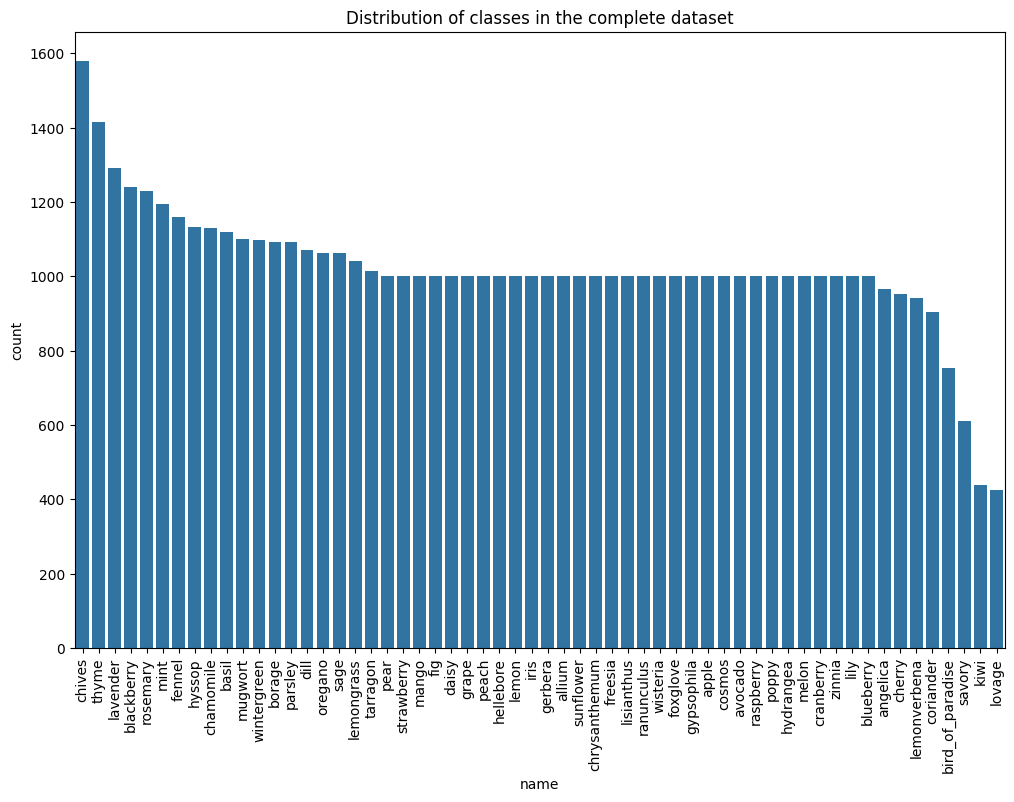

In [51]:
complete_label = pd.read_csv("../data/all_labels_all2.csv")
value_count_df = complete_label["name"].value_counts()
value_count_df = value_count_df.reset_index()
value_count_df.columns = ["name", "count"]
plt.figure(figsize=(12, 8))
sns.barplot(x="name", y="count", data=value_count_df)
plt.xticks(rotation=90)
plt.title("Distribution of classes in the complete dataset")
plt.show()

In [53]:
value_count_df

,name,count
0,chives,1579
1,thyme,1415
2,lavender,1291
3,blackberry,1240
4,rosemary,1229
5,mint,1194
6,fennel,1159
7,hyssop,1134
8,chamomile,1130
9,basil,1120


In [42]:
#count the number of files in the dir data/all_images
image_count = len([name for name in os.listdir("../data/all_images") if name.endswith(".jpg")])
print(f"Number of images in the directory: {image_count}")

Number of images in the directory: 26144


In [ ]:
complete_label["filename"]

59113

In [49]:
import os
from pathlib import Path
import shutil
from tqdm import tqdm

# === CONFIG ===
CSV_DF = complete_label
SRC_DIR = Path("../data/all_images")   # dossier source
DST_DIR = Path("../data/dataset")      # dossier destination

# Créer le dossier dataset s'il n'existe pas
DST_DIR.mkdir(parents=True, exist_ok=True)

# Récupérer toutes les classes
classes = sorted(CSV_DF["name"].unique())

# Créer un dossier par classe
for cls in classes:
    (DST_DIR / cls).mkdir(parents=True, exist_ok=True)

print(f"{len(classes)} classes détectées et dossiers créés.")

# Déplacer les images
errors = []

for idx, row in tqdm(CSV_DF.iterrows(), total=len(CSV_DF), desc="Moving images"):
    filename = row["filename"]
    cls = row["name"]

    src = SRC_DIR / filename
    dst = DST_DIR / cls / filename

    try:
        shutil.move(str(src), str(dst))
    except Exception as e:
        errors.append((filename, str(e)))

print("Terminé.")
print(f"Erreurs: {len(errors)}")

if errors:
    print("Quelques erreurs d'exemple:")
    print(errors[:5])

58 classes détectées et dossiers créés.


Moving images: 100%|██████████| 59113/59113 [00:02<00:00, 21766.26it/s]

Terminé.
Erreurs: 51112
Quelques erreurs d'exemple:
[('cosmos_0500.jpg', "[Errno 2] No such file or directory: '../data/all_images/cosmos_0500.jpg'"), ('cosmos_0501.jpg', "[Errno 2] No such file or directory: '../data/all_images/cosmos_0501.jpg'"), ('cosmos_0502.jpg', "[Errno 2] No such file or directory: '../data/all_images/cosmos_0502.jpg'"), ('cosmos_0503.jpg', "[Errno 2] No such file or directory: '../data/all_images/cosmos_0503.jpg'"), ('cosmos_0504.jpg', "[Errno 2] No such file or directory: '../data/all_images/cosmos_0504.jpg'")]


In [50]:
plant_name = set()

for error in errors:
    filename = error[0].split("_")[0]  # get the plant name from the filename
    plant_name.add(filename)
print("Plantes concernées par les erreurs:", plant_name)

Plantes concernées par les erreurs: {'lemon', 'oregano', 'hydrangea', 'origan', 'wisteria', 'wintergreen', 'kiwi', 'persil', 'blackberry', 'grape', 'chrysanthemum', 'coriandre1', 'sage', 'lemongrass', 'savory', 'gerbera', 'lemonverbena', 'angelica', 'thyme', 'lisianthus', 'thym', 'blueberry', 'ranunculus', 'sunflower', 'freesia', 'mango', 'lily', 'aneth', 'hyssop', 'poppy', 'romarin', 'dill', 'borage', 'basil', 'allium', 'foxglove', 'iris', 'chives', 'lovage', 'daisy', 'peach', 'gypsophila', 'fig', 'chamomile', 'lavender', 'mugwort', 'parsley', 'cranberry', 'zinnia', 'cosmos', 'avocado', 'menthe', 'raspberry', 'strawberry', 'melon', 'hellebore', 'coriander', 'apple', 'fennel', 'tarragon', 'bird', 'cherry', 'menthe1', 'pear', 'mint', 'rosemary', 'origan1'}
